# Model híbrid SARIMA-NNAR: Sèrie Temporal 2

Aquest notebook desenvolupa el model híbrid SARIMA-NNAR per a la sèrie Altres IRA – Barcelona Metropolitana Nord – 15 anys o més. L’objectiu és complementar el model SARIMA ajustat en el notebook "02_SARIMA_serie2", mitjançant una xarxa neuronal autoregressiva aplicada als residus, per valorar si aquesta correcció permet millorar la capacitat predictiva.

El procediment és el següent:

- Carregar el model SARIMA i ajustar-lo sobre el període d'entrenament
- Extreure els residus del SARIMA i dur a terme una anàlisi exploratòria per valorar si encara contenen estructura a modelitzar
- Construir una matriu d'aprenentatge supervisat a partir dels residus, utilitzant retards de curt termini i un retard estacional
- Dividir la sèrie de residus en entrenament i validació, preservant l'ordre temporal
- Cercar la millor combinació de nombre de retards curts i d'unitats ocultes mitjançant una graella de cerca
- Reajustar la xarxa neuronal seleccionada sobre tot el conjunt d'entrenament dels residus
- Generar prediccions recursives i combinar-les additivament amb les prediccions del SARIMA
- Construir intervals de predicció híbrids mitjançant bootstrap i calcular-ne la cobertura empírica.
- Avaluar el model híbrid respecte del SARIMA mitjançant MAE, RMSE, cobertura empírica i representacions gràfiques.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

COLOR_TRAIN = '#1f77b4'   
COLOR_OBS = '#ffbf00'      
COLOR_FORECAST = '#6a0dad' 
COLOR_HYBRID = "#009688"

df = pd.read_csv("dades_net.csv", sep=",")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["nom_regio", "diagnostic", "edat_bin", "date"]).copy()

In [2]:
df_serie = df[
    (df["diagnostic"] == "Altres IRA") &
    (df["nom_regio"] == "Barcelona Metropolitana Nord") &
    (df["edat_bin"] == "15+")
]

serie = (
    df_serie.groupby("date")["taxa_setmanal"]
    .sum()
    .sort_index()
)
serie = serie.asfreq("W-MON")

In [3]:
serie_2 = serie.copy()

train = serie_2[serie_2.index < "2020-01-01"]
test  = serie_2[serie_2.index >= "2020-01-01"]

train = train.interpolate()
test = test.interpolate()

2012-01-02 00:00:00 2019-12-30 00:00:00
2020-01-06 00:00:00 2024-12-23 00:00:00


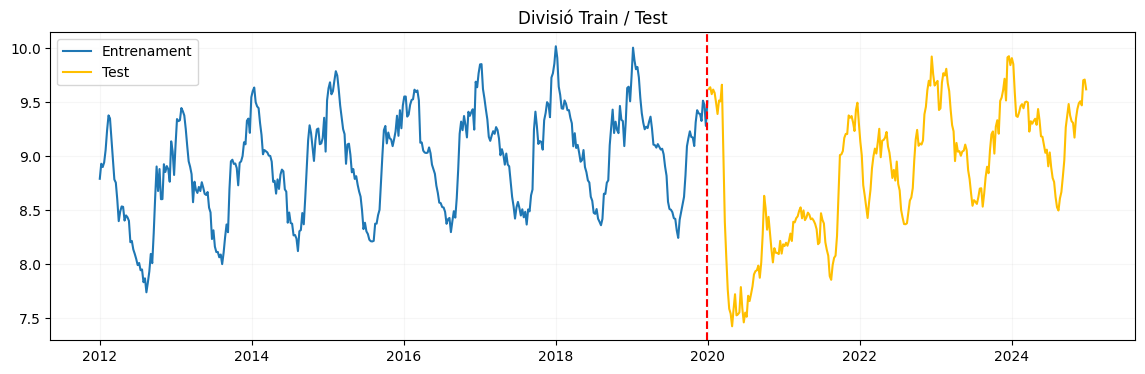

In [4]:
train_log = np.log1p(train)
test_log = np.log1p(test)

print(train_log.index.min(), train_log.index.max())
print(test_log.index.min(), test_log.index.max())

plt.figure(figsize=(14,4))

plt.plot(train_log, label="Entrenament", color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test_log, label="Test", color=COLOR_OBS, linewidth=1.5)

plt.axvline(train_log.index.max(), color="red", linestyle="--")

plt.grid(alpha=0.1)
plt.legend()
plt.title("Divisió Train / Test")
plt.show()

In [5]:
model = SARIMAX(train_log,
                order=(1,1,1),
                seasonal_order=(0,1,0,52),
                enforce_stationarity=False,
                enforce_invertibility=False)
result = model.fit(disp=False)

## Extracció de residus i anàlisi exploratòria

En aquesta secció s’extreuen els residus del model SARIMA ajustat sobre el conjunt d’entrenament. Aquests residus representen la part de la sèrie que queda sense explicar després de modelitzar-ne el comportament lineal i estacional principal.

A continuació, es duu a terme una anàlisi exploratòria dels residus mitjançant la seva mitjana, desviació estàndard, representació temporal, ACF i contrast de Ljung-Box en retards regulars i estacionals. L’objectiu és valorar si els residus es comporten aproximadament com un soroll blanc o si encara contenen estructura temporal que pugui justificar l’ús del model NNAR.

Burn-in utilitzat: 55
Mitjana dels residus: -0.011096494879039952


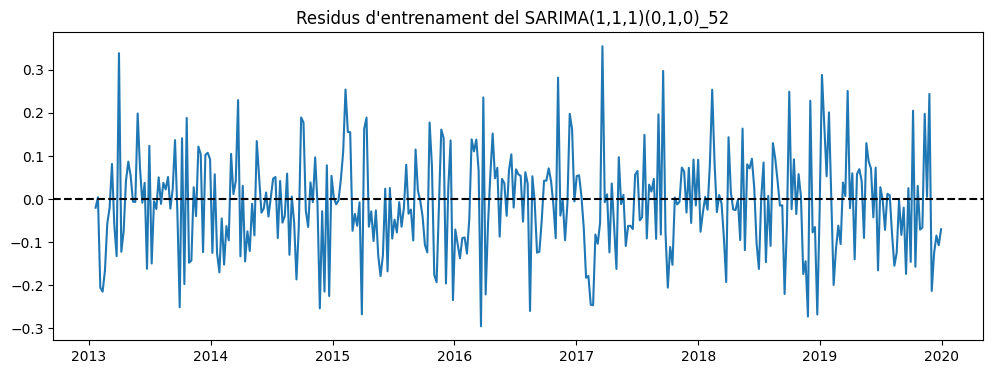

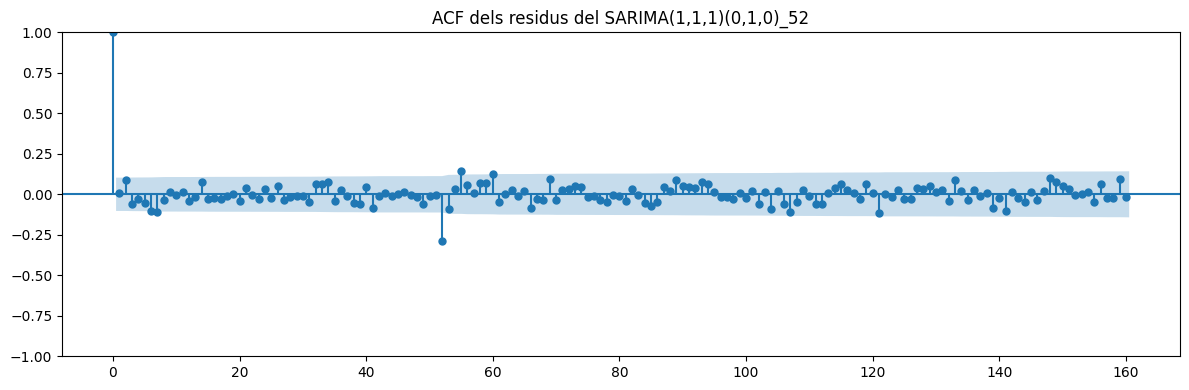


Ljung-Box test en retards regulars:
      lb_stat  lb_pvalue
10  14.037270   0.080799
20  18.491942   0.423715
30  21.932773   0.784394

Test de Ljung-Box en retards estacionals:
        lb_stat  lb_pvalue
52    72.780289   0.019377
104  140.049351   0.007433


In [6]:
residuals= result.resid.dropna()
burn = max(result.loglikelihood_burn, result.filter_results.nobs_diffuse)

print(f"Burn-in utilitzat: {burn}")
residuals_train = residuals.iloc[burn:].copy()

print("Mitjana dels residus:", residuals_train.mean())

plt.figure(figsize=(12, 4))
plt.plot(residuals_train)
plt.axhline(0, color="black", linestyle="--")
plt.title("Residus d'entrenament del SARIMA(1,1,1)(0,1,0)_52  ")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(residuals_train, lags=160, ax=ax)

ax.set_title("ACF dels residus del SARIMA(1,1,1)(0,1,0)_52")
plt.tight_layout()
plt.show()

model_df = 1 + 1 + 0 + 0

ljung_box = acorr_ljungbox(
    residuals_train,
    lags=[10, 20, 30],
    model_df=model_df,
    return_df=True
)

ljung_box_seasonal = acorr_ljungbox(
    residuals_train,
    lags=[52, 104],
    model_df=model_df,
    return_df=True
)
print("\nLjung-Box test en retards regulars:")
print(ljung_box)

print("\nTest de Ljung-Box en retards estacionals:")
print(ljung_box_seasonal)

## Resultats de l’anàlisi exploratòria dels residus

Els diagnòstics dels residus suggereixen que el model SARIMA captura una gran part de l’estructura lineal de la sèrie. Els residus fluctuen al voltant de zero i no mostren una dependència forta en retards curts.

Tanmateix, encara s’observa certa estructura restant en retards estacionals, especialment al voltant del retard 52. Això suggereix que podria persistir un petit patró estacional en la sèrie de residus.
Per aquest motiu, es considera un model NNAR amb component estacional com a possible complement del model SARIMA, amb l’objectiu d’avaluar si pot capturar aquesta estructura restant i millorar lleugerament les prediccions.

## Construcció de la matriu supervisada de residus

Per ajustar la xarxa neuronal, la sèrie de residus del SARIMA es transforma en un problema d’aprenentatge supervisat. Per a cada observació, les variables predictores són els p residus anteriors i un retard estacional de 52 setmanes. La variable objectiu és el residu actual.
Aquesta transformació permet tractar la sèrie temporal de residus com un problema de regressió, mantenint-ne l’estructura temporal.

In [7]:
SEASONAL_LAG = 52

ROLLING_START_FRAC = 0.7
ROLLING_HORIZON = 26
ROLLING_STEP = 26

p_list = [2, 3, 4, 5, 6, 8, 12]
hidden_list = [2, 3, 4, 6, 8]

def create_nnar_matrix(series, p=2, seasonal_lag=52):
    df = pd.DataFrame({"y": series})

    for i in range(1, p + 1):
        df[f"lag_{i}"] = series.shift(i)

    df[f"lag_seasonal_{seasonal_lag}"] = series.shift(seasonal_lag)

    df = df.dropna()

    X = df.drop(columns="y")
    y = df["y"]

    return X, y

## Graella dels hiperparàmetres del NNAR

Es realitza una cerca en graella per seleccionar l’especificació del model NNAR(p,1,h)_{52}. S’exploren diferents valors de (p), corresponents al nombre de retards regulars, i de (h), corresponents al nombre de neurones de la capa oculta. El component estacional es fixa en un retard de 52 setmanes.
Els models candidats s’avaluen mitjançant validació temporal amb finestra expansiva. En cada partició, el model s’entrena amb la part inicial de la sèrie de residus i es valida sobre el bloc següent. Les configuracions es comparen principalment segons el RMSE mitjà de validació, utilitzant el MAE com a mètrica complementària.

In [8]:
results_grid = []

n_total = len(residuals_train)
min_start = SEASONAL_LAG + max(p_list) + 10
start = max(int(np.floor(ROLLING_START_FRAC * n_total)), min_start)

for p in p_list:
    for hidden in hidden_list:
        fold_mae_list = []
        fold_rmse_list = []
        n_folds = 0

        end_train = start

        while end_train + ROLLING_HORIZON <= n_total:
            train_cv = residuals_train.iloc[:end_train].copy()
            val_cv = residuals_train.iloc[end_train:end_train + ROLLING_HORIZON].copy()

            X_train_nn, y_train_nn = create_nnar_matrix(
                train_cv,
                p=p,
                seasonal_lag=SEASONAL_LAG
            )

            if len(X_train_nn) == 0:
                end_train += ROLLING_STEP
                continue

            scaler_X = StandardScaler()
            scaler_y = StandardScaler()

            X_train_scaled = scaler_X.fit_transform(X_train_nn)
            y_train_scaled = scaler_y.fit_transform(y_train_nn.to_frame()).ravel()

            nnar_model = MLPRegressor(
                hidden_layer_sizes=(hidden,),
                activation="relu",
                solver="lbfgs",
                alpha=1e-4,
                max_iter=5000,
                random_state=42
            )

            nnar_model.fit(X_train_scaled, y_train_scaled)

            history = list(train_cv.values)
            pred_cv = []

            for _ in range(len(val_cv)):
                row_next = {}

                for i in range(1, p + 1):
                    row_next[f"lag_{i}"] = history[-i]

                row_next[f"lag_seasonal_{SEASONAL_LAG}"] = history[-SEASONAL_LAG]

                X_next = pd.DataFrame([row_next], columns=X_train_nn.columns)
                X_next_scaled = scaler_X.transform(X_next)

                pred_next_scaled = nnar_model.predict(X_next_scaled)
                pred_next = scaler_y.inverse_transform(
                    pred_next_scaled.reshape(-1, 1)
                ).ravel()[0]

                pred_cv.append(pred_next)
                history.append(pred_next)

            pred_cv = pd.Series(pred_cv, index=val_cv.index)

            mae_cv = mean_absolute_error(val_cv, pred_cv)
            rmse_cv = root_mean_squared_error(val_cv, pred_cv)

            fold_mae_list.append(mae_cv)
            fold_rmse_list.append(rmse_cv)
            n_folds += 1

            end_train += ROLLING_STEP

        if n_folds > 0:
            results_grid.append({
                "p": p,
                "P": 1,
                "m": SEASONAL_LAG,
                "hidden_units": hidden,
                "rolling_MAE": np.mean(fold_mae_list),
                "rolling_RMSE": np.mean(fold_rmse_list),
            })

results_grid = (
    pd.DataFrame(results_grid)
    .sort_values(["rolling_RMSE", "rolling_MAE"])
    .reset_index(drop=True)
)

print("\nTop 5 configuracions segons el menor RMSE mitjà")
display(
    results_grid
    .sort_values(["rolling_RMSE", "rolling_MAE"])
    .head(5)
    .reset_index(drop=True)
    .rename(columns={
        "hidden_units": "neurones (h)",
        "rolling_MAE": "MAE mitjà",
        "rolling_RMSE": "RMSE mitjà",
    })
)


Top 5 configuracions segons el menor RMSE mitjà


,p,P,m,neurones (h),MAE mitjà,RMSE mitjà
0,6,1,52,8,0.082367,0.102131
1,8,1,52,2,0.082980,0.105498
2,2,1,52,4,0.080937,0.105543
3,4,1,52,6,0.082965,0.106294
4,5,1,52,4,0.085180,0.106450


In [9]:
best_config = results_grid.iloc[0]

best_p = int(best_config["p"])
best_hidden = int(best_config["hidden_units"])

print("NNAR seleccionat:")
print(f"p = {best_p}")
print("P = 1")
print(f"m = {SEASONAL_LAG}")
print(f"neurones ocultes = {best_hidden}")
print(f"MAE mitjà = {best_config['rolling_MAE']:.6f}")
print(f"RMSE mitjà = {best_config['rolling_RMSE']:.6f}")

NNAR seleccionat:
p = 6
P = 1
m = 52
neurones ocultes = 8
MAE mitjà = 0.082367
RMSE mitjà = 0.102131


## Ajust final del NNAR sobre tot el conjunt d’entrenament dels residus

Un cop seleccionada la millor configuració, el model NNAR estacional s’ajusta de nou utilitzant tot el conjunt d’entrenament dels residus. Per a aquesta sèrie, el model seleccionat és **NNAR(6,1,8)_{52}**
Això significa que s’utilitzen sis retards regulars dels residus, un retard estacional de 52 setmanes i vuit neurones a la capa oculta

In [10]:
X_full_nn, y_full_nn = create_nnar_matrix(residuals_train, p=best_p, seasonal_lag=SEASONAL_LAG)

scaler_X_final = StandardScaler()
scaler_y_final = StandardScaler()

X_full_scaled = scaler_X_final.fit_transform(X_full_nn)
y_full_scaled = scaler_y_final.fit_transform(y_full_nn.to_frame()).ravel()

nnar_final = MLPRegressor(
    hidden_layer_sizes=(best_hidden,),
    activation="relu",
    solver="lbfgs",
    alpha=1e-4,
    max_iter=5000,
    random_state=42
)

nnar_final.fit(X_full_scaled, y_full_scaled);

## Predicció recursiva dels residus i predicció híbrida

Les prediccions dels residus es generen de manera recursiva. Això vol dir que la xarxa neuronal prediu el següent valor residual utilitzant els retards disponibles més recents i el retard estacional. Després, cada residu predit s’incorpora a l’historial i s’utilitza per predir el següent. Aquesta estratègia recursiva és necessària perquè en l’horitzó de predicció, els residus futurs són desconeguts i, per tant, s’han de generar pas a pas.

Finalment, les prediccions dels residus obtingudes amb el model NNAR estacional s’afegeixen a les prediccions del SARIMA en l’escala transformada logarítmicament. 

In [11]:
def recursive_nnar_forecast(model, history, horizon, p, seasonal_lag, scaler_X, scaler_y, forecast_index):
    preds = []
    history = list(history)

    for _ in range(horizon):
        row = {}

        for i in range(1, p + 1):
            row[f"lag_{i}"] = history[-i]

        row[f"lag_seasonal_{seasonal_lag}"] = history[-seasonal_lag]

        X_next = pd.DataFrame([row])
        X_next_scaled = scaler_X.transform(X_next)

        pred_scaled = model.predict(X_next_scaled)
        pred = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()[0]

        preds.append(pred)
        history.append(pred)

    return pd.Series(preds, index=forecast_index)

## Intervals de predicció per al model híbrid

Per al model SARIMA, els intervals de predicció s’obtenen directament del model ajustat.  
En el cas de l’enfocament híbrid SARIMA + NNAR, això no és tan directe, ja que el component de xarxa neuronal no proporciona intervals de predicció analítics exactes.

Per abordar-ho, els intervals híbrids es construeixen mitjançant simulació. Primer, se simulen trajectòries futures per al component SARIMA. Després, es generen recursivament trajectòries futures dels residus per al component NNAR, afegint errors passats remostrejats (*bootstrap*) per reflectir la incertesa. Finalment, es combinen totes dues parts i es prenen els quantils del 2,5% i del 97,5% de les trajectòries simulades com a límit inferior i superior de l’interval de predicció del 95%.

Per tant, aquests intervals s’han d’interpretar com a intervals de predicció empírics o aproximats, no com a intervals analítics exactes.

In [12]:
def hybrid_pi_short(
    sarima_result,
    nnar_model,
    scaler_X,
    scaler_y,
    residuals_train,
    X_train_nnar,
    y_train_nnar,
    p,
    seasonal_lag,
    forecast_index,
    n_sims=300,
    alpha=0.05,
    seed=42
):
    rng = np.random.default_rng(seed)
    h = len(forecast_index)

    X_scaled = scaler_X.transform(X_train_nnar)
    yhat_scaled = nnar_model.predict(X_scaled)
    yhat = scaler_y.inverse_transform(yhat_scaled.reshape(-1, 1)).ravel()

    nnar_errors = np.asarray(y_train_nnar) - yhat
    nnar_errors = nnar_errors - nnar_errors.mean()

    err_low, err_high = np.quantile(nnar_errors, [0.01, 0.99])
    nnar_errors = np.clip(nnar_errors, err_low, err_high)

    sarima_sim = np.asarray(
        sarima_result.simulate(
            nsimulations=h,
            repetitions=n_sims,
            anchor="end",
            random_state=seed
        )
    )

    if sarima_sim.ndim == 1:
        sarima_sim = sarima_sim.reshape(h, 1)
    elif sarima_sim.shape == (n_sims, h):
        sarima_sim = sarima_sim.T

    hybrid_sim = np.zeros((h, n_sims))
    base_history = list(np.asarray(residuals_train, dtype=float))

    resid_low, resid_high = np.quantile(base_history, [0.01, 0.99])

    for b in range(n_sims):
        history = base_history.copy()

        for t in range(h):
            row = {f"lag_{i}": history[-i] for i in range(1, p + 1)}
            row[f"lag_seasonal_{seasonal_lag}"] = history[-seasonal_lag]

            X_next = pd.DataFrame([row])
            X_next_scaled = scaler_X.transform(X_next)

            pred_scaled = nnar_model.predict(X_next_scaled)
            pred_resid = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()[0]

            next_resid = pred_resid + rng.choice(nnar_errors)
            next_resid = np.clip(next_resid, resid_low, resid_high)
            history.append(next_resid)

            total_log = sarima_sim[t, b] + next_resid
            total_log = np.clip(total_log, -20, 20)
            hybrid_sim[t, b] = np.expm1(total_log)

    lower = pd.Series(np.quantile(hybrid_sim, alpha / 2, axis=1), index=forecast_index)
    upper = pd.Series(np.quantile(hybrid_sim, 1 - alpha / 2, axis=1), index=forecast_index)
    median = pd.Series(np.quantile(hybrid_sim, 0.5, axis=1), index=forecast_index)

    return lower, upper, median

In [13]:
pred = result.get_forecast(steps=len(test_log))
pred_mean_log = pred.predicted_mean
pred_ci_log = pred.conf_int()

nnar_resid_forecast = recursive_nnar_forecast(
    model=nnar_final,
    history=residuals_train.values,
    horizon=len(test_log),
    p=best_p,
    seasonal_lag=SEASONAL_LAG,
    scaler_X=scaler_X_final,
    scaler_y=scaler_y_final,
    forecast_index=test_log.index
)

hybrid_pred_mean_log = pred_mean_log + nnar_resid_forecast

pred_mean = np.expm1(pred_mean_log)
pred_ci = np.expm1(pred_ci_log)
hybrid_pred_mean = np.expm1(hybrid_pred_mean_log)

hybrid_ci_lower, hybrid_ci_upper, hybrid_ci_median = hybrid_pi_short(
    sarima_result=result,
    nnar_model=nnar_final,
    scaler_X=scaler_X_final,
    scaler_y=scaler_y_final,
    residuals_train=residuals_train,
    X_train_nnar=X_full_nn,     
    y_train_nnar=y_full_nn,     
    p=best_p,
    seasonal_lag=SEASONAL_LAG,
    forecast_index=test.index,
    n_sims=300,
    alpha=0.05,
    seed=42
)

## Model SARIMA vs model híbrid

Finalment, es compara el rendiment predictiu del model SARIMA i del model híbrid SARIMA-NNAR sobre el període de test. La comparació es basa en el MAE, l’RMSE i la cobertura empírica dels intervals de predicció.
L’avaluació es realitza per al període total de test i, separadament, per als subperíodes COVID i post-COVID, per tal d’analitzar si el comportament dels models varia entre el període més irregular i el període posterior de major estabilitat.

In [14]:
test_covid = test["2020":"2021"]
test_post = test["2022":"2024"]

pred_covid = pred_mean["2020":"2021"]
pred_post = pred_mean["2022":"2024"]

hybrid_covid = hybrid_pred_mean["2020":"2021"]
hybrid_post = hybrid_pred_mean["2022":"2024"]

ci_covid = pred_ci.loc["2020":"2021"]
ci_post = pred_ci.loc["2022":"2024"]

hybrid_ci_covid_lower = hybrid_ci_lower["2020":"2021"]
hybrid_ci_covid_upper = hybrid_ci_upper["2020":"2021"]

hybrid_ci_post_lower = hybrid_ci_lower["2022":"2024"]
hybrid_ci_post_upper = hybrid_ci_upper["2022":"2024"]

mae_sarima_total = mean_absolute_error(test, pred_mean)
rmse_sarima_total = root_mean_squared_error(test, pred_mean)
cov_sarima_total = ((test >= pred_ci.iloc[:, 0]) & (test <= pred_ci.iloc[:, 1])).mean()

mae_hybrid_total = mean_absolute_error(test, hybrid_pred_mean)
rmse_hybrid_total = root_mean_squared_error(test, hybrid_pred_mean)
cov_hybrid_total = ((test >= hybrid_ci_lower) & (test <= hybrid_ci_upper)).mean()

mae_sarima_covid = mean_absolute_error(test_covid, pred_covid)
rmse_sarima_covid = root_mean_squared_error(test_covid, pred_covid)
cov_sarima_covid = ((test_covid >= ci_covid.iloc[:, 0]) & (test_covid <= ci_covid.iloc[:, 1])).mean()

mae_hybrid_covid = mean_absolute_error(test_covid, hybrid_covid)
rmse_hybrid_covid = root_mean_squared_error(test_covid, hybrid_covid)
cov_hybrid_covid = ((test_covid >= hybrid_ci_covid_lower) & (test_covid <= hybrid_ci_covid_upper)).mean()

mae_sarima_post = mean_absolute_error(test_post, pred_post)
rmse_sarima_post = root_mean_squared_error(test_post, pred_post)
cov_sarima_post = ((test_post >= ci_post.iloc[:, 0]) & (test_post <= ci_post.iloc[:, 1])).mean()

mae_hybrid_post = mean_absolute_error(test_post, hybrid_post)
rmse_hybrid_post = root_mean_squared_error(test_post, hybrid_post)
cov_hybrid_post = ((test_post >= hybrid_ci_post_lower) & (test_post <= hybrid_ci_post_upper)).mean()

table_total = pd.DataFrame({
    "Model": ["SARIMA", "Híbrid"],
    "MAE": [mae_sarima_total, mae_hybrid_total],
    "RMSE": [rmse_sarima_total, rmse_hybrid_total],
    "Cobertura": [cov_sarima_total, cov_hybrid_total]
}).round({"MAE": 3, "RMSE": 3, "Cobertura": 3 })

table_covid = pd.DataFrame({
    "Model": ["SARIMA", "Híbrid"],
    "MAE": [mae_sarima_covid, mae_hybrid_covid],
    "RMSE": [rmse_sarima_covid, rmse_hybrid_covid],
    "Cobertura": [cov_sarima_covid, cov_hybrid_covid]
}).round({"MAE": 3, "RMSE": 3, "Cobertura": 3})

table_post = pd.DataFrame({
    "Model": ["SARIMA", "Híbrid"],
    "MAE": [mae_sarima_post, mae_hybrid_post],
    "RMSE": [rmse_sarima_post, rmse_hybrid_post],
    "Cobertura": [cov_sarima_post, cov_hybrid_post]
}).round({"MAE": 3, "RMSE": 3, "Cobertura": 3})

print("\nTOTAL (2020-2024):")
display(table_total)

print("\nCOVID (2020–2021):")
display(table_covid)

print("\nPOST-COVID (2022–2024):")
display(table_post)


TOTAL (2020-2024):


,Model,MAE,RMSE,Cobertura
0,SARIMA,3115.791,4281.233,0.723
1,Híbrid,3090.745,4254.093,0.735



COVID (2020–2021):


,Model,MAE,RMSE,Cobertura
0,SARIMA,4281.722,5407.154,0.375
1,Híbrid,4221.001,5368.023,0.404



POST-COVID (2022–2024):


,Model,MAE,RMSE,Cobertura
0,SARIMA,2338.504,3325.165,0.955
1,Híbrid,2337.242,3309.341,0.955


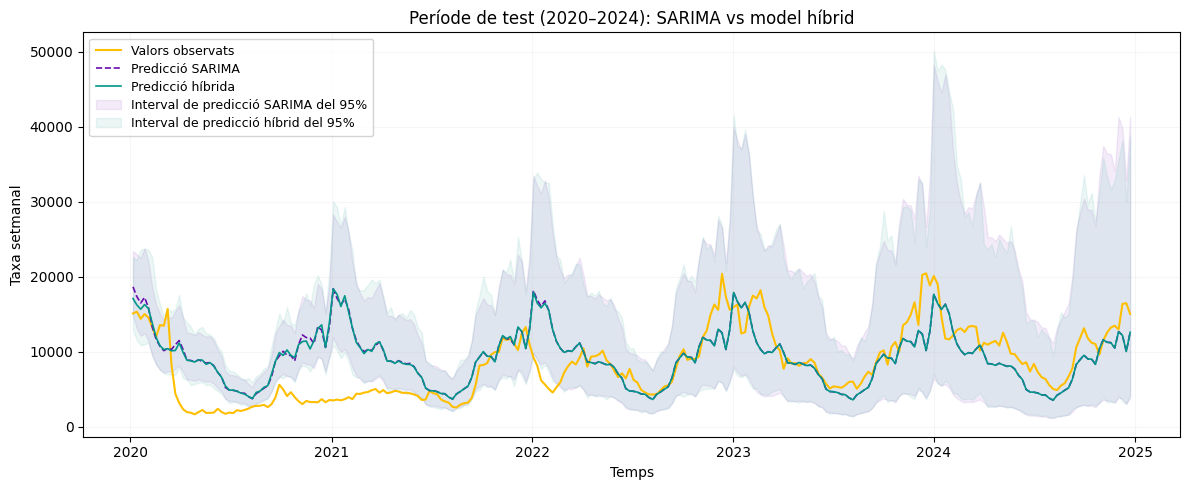

In [15]:
plt.figure(figsize=(12,5))

plt.plot(test, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Predicció SARIMA', color=COLOR_FORECAST, linewidth=1.2, linestyle='--')
plt.plot(hybrid_pred_mean, label='Predicció híbrida', color=COLOR_HYBRID, linewidth=1.2)

plt.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    color=COLOR_FORECAST,
    alpha=0.08,
    label='Interval de predicció SARIMA del 95%'
)

plt.fill_between(
    hybrid_ci_lower.index,
    hybrid_ci_lower.values,
    hybrid_ci_upper.values,
    color=COLOR_HYBRID,
    alpha=0.08,
    label='Interval de predicció híbrid del 95%'
)

plt.title("Període de test (2020–2024): SARIMA vs model híbrid")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal")

plt.legend(
    fontsize=9,
    loc='upper left',
    framealpha=0.85,
    borderpad=0.5,
    labelspacing=0.4,
    handlelength=2
)

plt.grid(alpha=0.1)
plt.tight_layout()
plt.show()

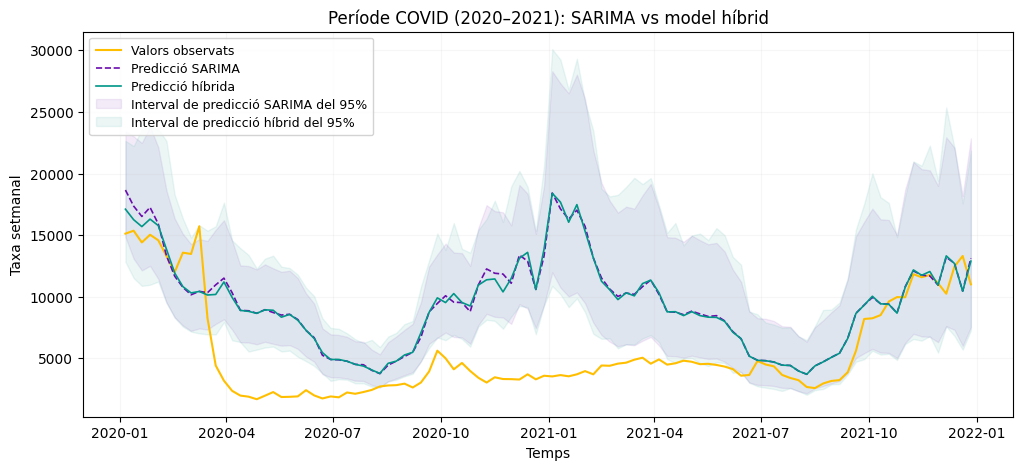

In [16]:
hybrid_covid = hybrid_pred_mean["2020":"2021"]

plt.figure(figsize=(12,5))

plt.plot(test_covid, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_covid, label='Predicció SARIMA', color=COLOR_FORECAST, linewidth=1.2, linestyle='--')
plt.plot(hybrid_covid, label='Predicció híbrida', color=COLOR_HYBRID, linewidth=1.2)

plt.fill_between(
    ci_covid.index,
    ci_covid.iloc[:, 0],
    ci_covid.iloc[:, 1],
    color=COLOR_FORECAST,
    alpha=0.08,
    label='Interval de predicció SARIMA del 95%'
)

plt.fill_between(
    hybrid_ci_covid_lower.index,
    hybrid_ci_covid_lower.values,
    hybrid_ci_covid_upper.values,
    color=COLOR_HYBRID,
    alpha=0.08,
    label='Interval de predicció híbrid del 95%'
)

plt.title("Període COVID (2020–2021): SARIMA vs model híbrid")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal")
plt.legend(
    fontsize=9,
    loc='upper left',
    framealpha=0.85,
    borderpad=0.5,
    labelspacing=0.4,
    handlelength=2
)

plt.grid(alpha=0.1)
plt.show()

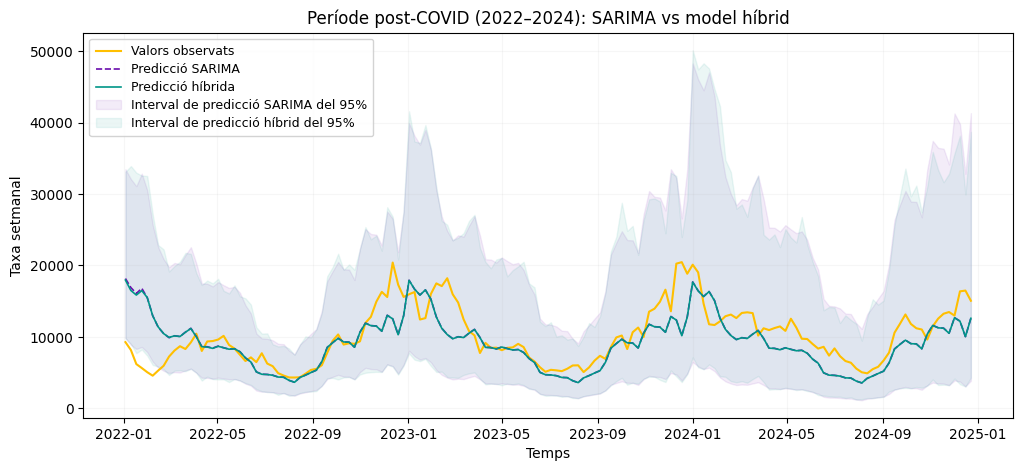

In [17]:
hybrid_post = hybrid_pred_mean["2022":"2024"]

plt.figure(figsize=(12,5))

plt.plot(test_post, label='Valors observats', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_post, label='Predicció SARIMA', color=COLOR_FORECAST, linewidth=1.2, linestyle='--')
plt.plot(hybrid_post, label='Predicció híbrida', color=COLOR_HYBRID, linewidth=1.2)

plt.fill_between(
    ci_post.index,
    ci_post.iloc[:, 0],
    ci_post.iloc[:, 1],
    color=COLOR_FORECAST,
    alpha=0.08,
    label='Interval de predicció SARIMA del 95%'
)

plt.fill_between(
    hybrid_ci_post_lower.index,
    hybrid_ci_post_lower.values,
    hybrid_ci_post_upper.values,
    color=COLOR_HYBRID,
    alpha=0.08,
    label='Interval de predicció híbrid del 95%'
)

plt.title("Període post-COVID (2022–2024): SARIMA vs model híbrid")
plt.xlabel("Temps")
plt.ylabel("Taxa setmanal")
plt.legend(
    fontsize=9,
    loc='upper left',
    framealpha=0.85,
    borderpad=0.5,
    labelspacing=0.4,
    handlelength=2
)

plt.grid(alpha=0.1)
plt.show()